####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

#### If you have time (or later at home...)

- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import numpy as np

(35.0, 50.0)

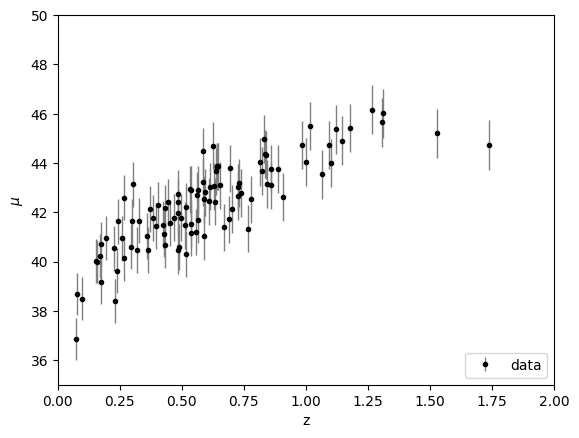

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

We want to first fit the data both with linear and polinomial regression.

In [3]:
from astroML.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression

C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


## Linear regression

In [4]:
linear_model = LinearRegression()
linear_model.fit(z_sample[:, None], mu_sample, dmu)

print(linear_model.coef_)

[39.48384602  4.76438865]


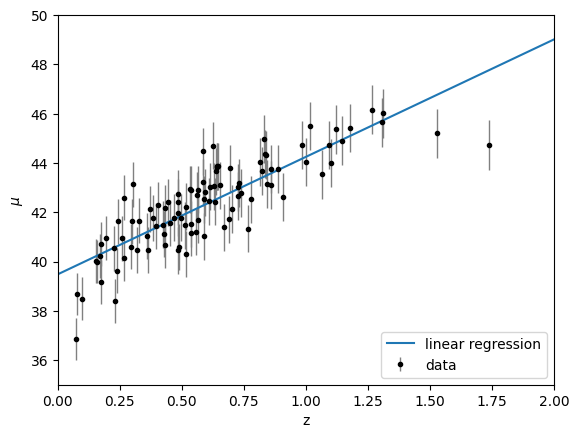

In [5]:
x = np.linspace(0, 2, 100)
f = linear_model.coef_[0] + linear_model.coef_[1] * x
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x, f, label = 'linear regression')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

## Polynomial regression

In [6]:
poly_model = []
for i in range(2, 14):
    poly_model.append(PolynomialRegression(degree = i))
    poly_model[i-2].fit(z_sample[:, None], mu_sample, dmu)

print(poly_model[0].coef_)

[38.41076899  8.59831905 -2.64090751]


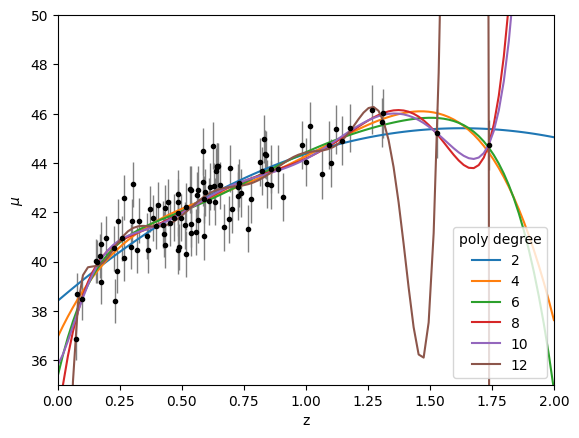

In [7]:
x = np.linspace(0, 2, 100)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
for p in poly_model[::2]:
    f = np.zeros(100)
    for j in range(len(p.coef_)):
        f += p.coef_[j] * x**j
    plt.plot(x, f, label = str(len(p.coef_) - 1))

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(title = 'poly degree', loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

Higher (>=6) degrees seem to overfit the data, while a Linear Regression underfits it. Let's draw only the lines which seem to fit the data best.

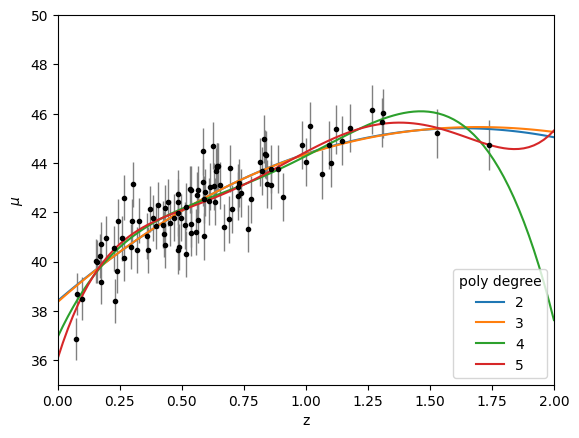

In [8]:
x = np.linspace(0, 2, 100)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
for p in poly_model[:4]:
    f = np.zeros(100)
    for j in range(len(p.coef_)):
        f += p.coef_[j] * x**j
    plt.plot(x, f, label = str(len(p.coef_) - 1))

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(title = 'poly degree', loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

The 2nd and 2rd degree fits look the most promising, the 4th/5th degree fit seem to be overfitting to "catch" the last point. 

## Basis function regression

In [9]:
from astroML.linear_model import BasisFunctionRegression

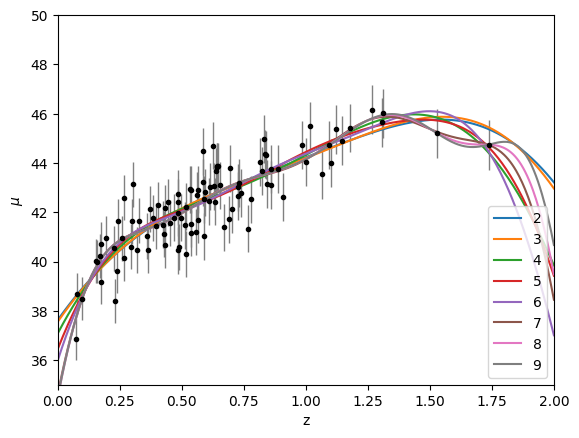

In [10]:
#print(np.mean(z_sample))
x = np.linspace(0, 2, 500)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

for n in range(2, 10):
    basis_mu = np.linspace(0, 2, n)
    basis_sigma = 2 / n
    bfr = BasisFunctionRegression('gaussian', mu = basis_mu[:, None], sigma = basis_sigma)
    bfr.fit(z_sample[:, None], mu_sample, dmu)
    f = bfr.predict(x[:, None])
    plt.plot(x, f, label = str(n))
    
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

## Kernel Regression

In [11]:
from astroML.linear_model import NadarayaWatson

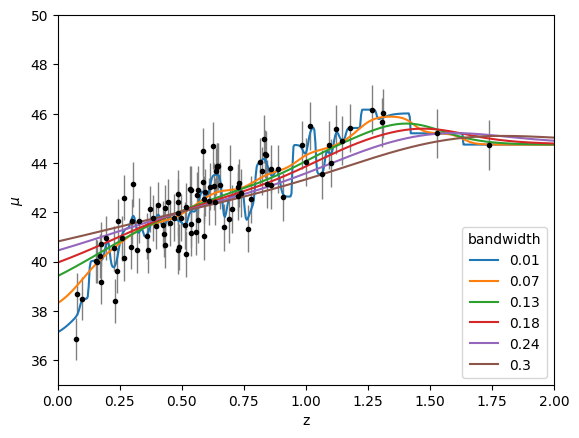

In [12]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

h_range = np.round(np.linspace(0.01, 0.3, 6), 2)
for bw in h_range:
    kr = NadarayaWatson(kernel='gaussian', h = bw)
    kr.fit(z_sample[:, None], mu_sample, dmu)
    f = kr.predict(x[:, None])
    plt.plot(x, f, label = str(bw))

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(title = 'bandwidth', loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

## Model selection
To pick the actual best line, we want to split our data into training and validation and analyse our error function.

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = np.copy(z_sample[:, None])
y = np.copy(mu_sample)
dy = np.copy(dmu)

X_train, X_val, ydy_train, ydy_val = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state = 4)
y_train,dy_train = ydy_train.T
y_val,dy_val = ydy_val.T

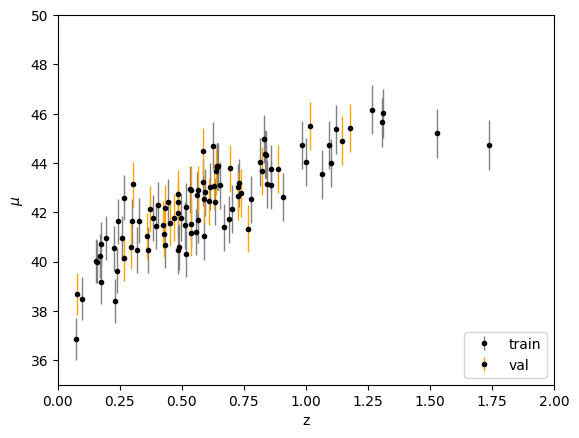

In [15]:
plt.errorbar(X_train[:], y_train, dy_train, fmt='.k', ecolor='gray', lw=1, label='train')
plt.errorbar(X_val[:], y_val, dy_val, fmt='.k', ecolor='orange', lw=1, label='val')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

In [16]:
def error_func(X, y, model):
    return np.sqrt( (1/len(X)) * (np.sum((y - model.predict(X)) ** 2)) )
    
def get_err (model):
    model.fit(X_train, y_train, dy_train)
    error_train = error_func(X_train, y_train, model)
    error_val = error_func(X_val, y_val, model)
    return error_train, error_val

### Linear regression error

In [17]:
model = LinearRegression()
err_train, err_val = get_err (model)
print('error on training set: ', err_train, '; error on validation set: ', err_val)

error on training set:  1.0188013256951085 ; error on validation set:  0.9321841872588656


### Polynomial regression error

Degree	Train error		CV error
2 	 0.9235468763037449 	 0.867209917231861
3 	 0.9224912312738244 	 0.8705953179369337
4 	 0.892495403715648 	 0.8297698765008786
5 	 0.8801608222013984 	 0.8451252966585694
6 	 0.8687481761586503 	 0.8846979198518361
7 	 0.8373407929508497 	 0.9288539494680494
8 	 0.8355634764012203 	 0.9346078010748256
9 	 0.8347670406494098 	 0.9337161016547987
10 	 0.8305522603257475 	 0.9615933181957539
11 	 0.8284524651382768 	 0.9581267609353973
12 	 0.818048746469063 	 0.9339412439059226
13 	 0.8180093226254744 	 0.930253299338521
14 	 0.7989277177085828 	 0.9597209688785605
15 	 0.798919406264418 	 0.9630396840474609
16 	 0.7985249593934309 	 0.9407218789828958
17 	 0.7986869947214467 	 0.9434078379894943
18 	 0.7987058992682617 	 0.9515354283374234
19 	 0.7982424643998228 	 0.9647934624053992


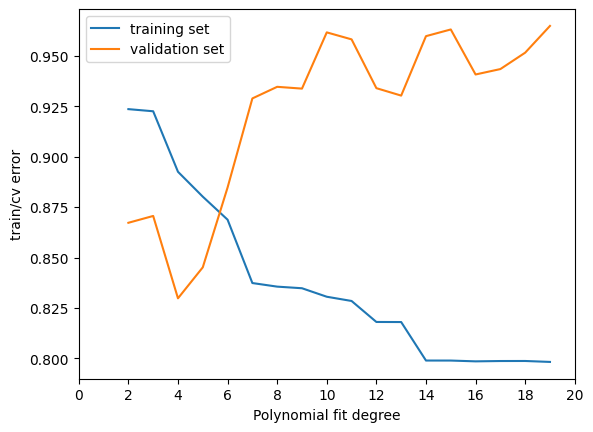

In [18]:
err_train = []
err_val = []

print('Degree\tTrain error\t\tCV error')
for n in range(2, 20):
    model = PolynomialRegression(degree = n)
    a, b = get_err(model)
    print(n, '\t', a, '\t', b)
    err_train.append(a)
    err_val.append(b)

plt.plot(range(2, 20), err_train, label = 'training set')
plt.plot(range(2, 20), err_val, label = 'validation set')
plt.xlabel('Polynomial fit degree')
plt.ylabel('train/cv error')
plt.xticks(np.linspace(0, 20, 11))
plt.legend()
plt.show()

If the validation set takes one of the two 'outliers' into account, the errors skyrocket at high degree, pick i.e. random_state = 3.

In [19]:
print('The best line is the ', np.argmin(err_val) + 2, 'th degree one.')

The best line is the  4 th degree one.


### Basis Function Regression error

n	Train error		CV error
2 	 0.9085777881341434 	 0.8397322000652226
3 	 0.9086234585968158 	 0.8398396557096834
4 	 0.8935342933219642 	 0.8283686928517038
5 	 0.8833265956516363 	 0.8516241867057266
6 	 0.8689705646113149 	 0.8950170046601619
7 	 0.8351369641750414 	 0.9317573275396004
8 	 0.8342793324851103 	 0.9351444318118615
9 	 0.8339134824940744 	 0.9384932004488667
10 	 0.8334115051053416 	 0.9419043927287393
11 	 0.8310230993997019 	 0.9305401678220634
12 	 0.8318209104077761 	 0.9349658225583392
13 	 0.8096774107782095 	 1.0151644219918334
14 	 0.798317082129082 	 0.9404834532902735


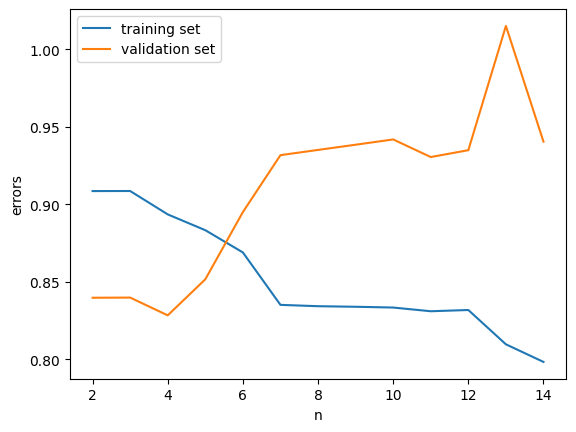

In [20]:
err_train = []
p_err_val = []

print('n\tTrain error\t\tCV error')
for n in range(2, 15):
    basis_mu = np.linspace(0, 2, n)
    basis_sigma = 2 / n
    model = BasisFunctionRegression('gaussian', mu = basis_mu[:, None], sigma = basis_sigma)
    a, b = get_err(model)
    print(n, '\t', a, '\t', b)
    err_train.append(a)
    p_err_val.append(b)

plt.plot(range(2, 15), err_train, label = 'training set')
plt.plot(range(2, 15), p_err_val, label = 'validation set')
plt.xlabel('n')
plt.ylabel('errors')
plt.legend()
plt.show()

In [21]:
print('Best line n=',range(2, 15)[np.argmin(p_err_val)])

Best line n= 4


### Kernel regression error

BW	Train error		CV error
0.01 	 0.564089398710977 	 1.0538178253687185
0.07 	 0.8641831439144604 	 0.8678458596182564
0.13 	 0.9451439154848452 	 0.9007559872407506
0.18 	 0.9997615527728736 	 0.936191075875313
0.24 	 1.087885975633318 	 1.0041531966238537
0.3 	 1.1882006301080135 	 1.0798718825367704


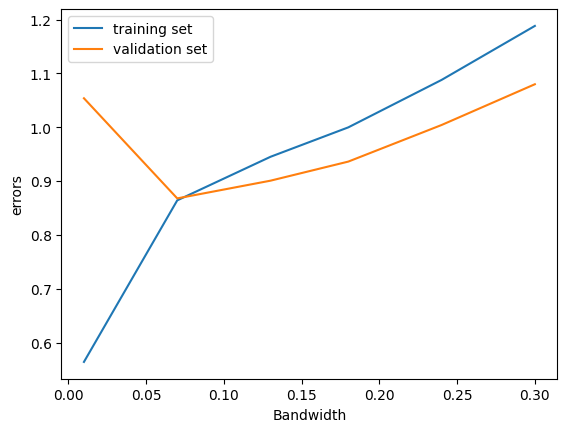

In [22]:
err_train = []
err_val = []

print('BW\tTrain error\t\tCV error')
for bw in h_range:
    model = NadarayaWatson(kernel='gaussian', h = bw)
    a, b = get_err(model)
    print(bw, '\t', a, '\t', b)
    err_train.append(a)
    err_val.append(b)

plt.plot(h_range, err_train, label = 'training set')
plt.plot(h_range, err_val, label = 'validation set')
plt.xlabel('Bandwidth')
plt.ylabel('errors')
plt.legend()
plt.show()

Let's instead try to do it using GridSearchCV

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [24]:
pipe = Pipeline([('Regressor', LinearRegression())])

parameters = [
    {
        'Regressor':[LinearRegression()]
    },
    {
        'Regressor':[PolynomialRegression()],
        'Regressor__degree':np.arange(2, 10)
    }
    
]

#GridSearchCv picks the highest score  -> using negative RMSE it picks the smallest instead
grid_search = GridSearchCV(pipe, param_grid=parameters, cv=5, scoring='neg_root_mean_squared_error', verbose = 1, n_jobs=-1)
grid_search.fit(X, y, Regressor__y_error=dy)

grid_search.best_params_

Fitting 5 folds for each of 9 candidates, totalling 45 fits


{'Regressor': PolynomialRegression(), 'Regressor__degree': np.int64(2)}

In [25]:
results = grid_search.cv_results_
results.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_Regressor', 'param_Regressor__degree', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [26]:
means = results['mean_test_score']
reg = results['param_Regressor'].data
degree = results['param_Regressor__degree'].data

In [27]:
import seaborn as sns

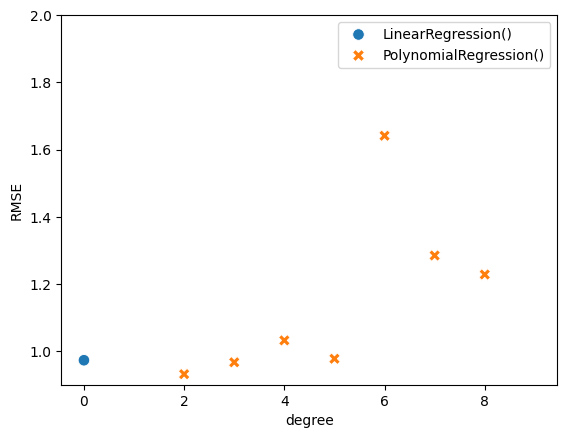

In [28]:
sns.scatterplot(x = degree, y = -means, hue = reg, style = reg, s = 70).set(xlabel='degree', ylabel='RMSE', ylim =[0.9, 2])
plt.show()

The results are different but it is probably due to the train/validation split: we are only testing the errors on one split -> the result depends on which points are in each split, while with cross-val it is run over n_cv=5 different splits and averaged.

In [29]:
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)

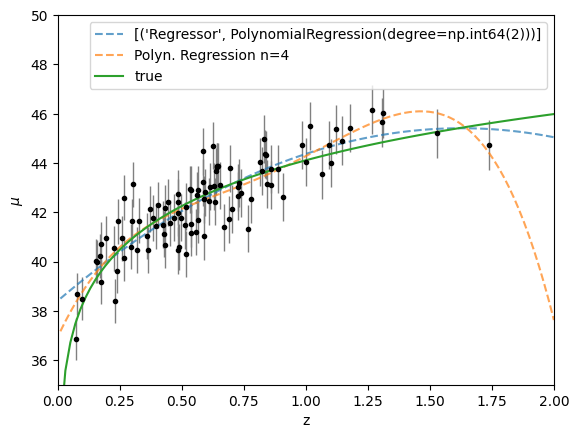

In [30]:
best_model = grid_search.best_estimator_
#best_model.fit(X, y, Regressor__y_error=dy)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
x= np.linspace(0.01, 2, 100)
f = best_model.predict(x[:, None])
plt.plot(x, f, ls = 'dashed', alpha = 0.7, label = str(best_model.steps))


p = poly_model[np.argmin(p_err_val)]
f_ = np.zeros(100)
for j in range(len(p.coef_)):
        f_ += p.coef_[j] * x**j
plt.plot(x, f_, ls = 'dashed', alpha = 0.7, label = 'Polyn. Regression n=' + str(len(p.coef_) - 1))


mu_true = cosmo.distmod(x)
plt.plot(x, mu_true, label = 'true')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend()
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

## Learning curves

In [31]:
def error_func(X, y, model):
    return np.sqrt( (1/len(X)) * (np.sum((y - model.predict(X)) ** 2)) )

In [32]:
train_err = []
cv_err = []

npoints = np.linspace(10, 70, 7, dtype = int)
for n in npoints:
    best_model.fit(X_train[:n], y_train[:n], Regressor__y_error=dy_train[:n])
    train_err.append( error_func(X_train[:n], y_train[:n], best_model) )
    cv_err.append( error_func(X_val, y_val, best_model) )

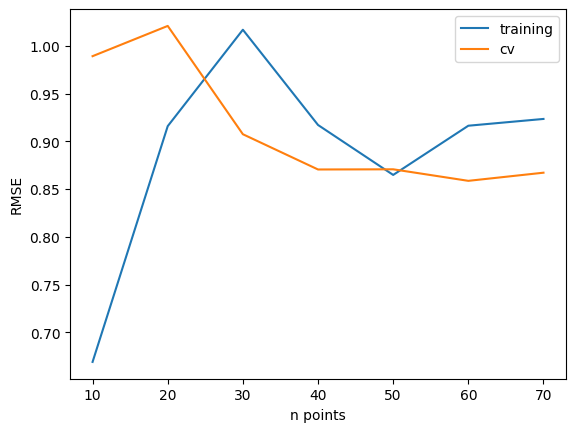

In [33]:
plt.plot(npoints, train_err, label='training')
plt.plot(npoints, cv_err, label='cv')
plt.xlabel('n points')
plt.ylabel('RMSE')
plt.legend()

The curves seem to be stabilizing, meaning that adding more points wouldn't decrease the error significantly.